In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice, cycle

Fontconfig warning: ignoring UTF-8: not a valid region tag


In [2]:
chromatic = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']

# a function which gets initial note and cycle through the N notes
def cycle_notes(root_note, univ_scale, N):
    root_idx = univ_scale.index(root_note)
    return list(islice(cycle(univ_scale), root_idx, root_idx + N))

#major scale intervals
maj_int = [2, 2, 1, 2, 2, 2, 1]
#minor scale intervals
min_int = [2, 1, 2, 2, 1, 2, 2]
#pentatonic scale intervals
pent_int = [2, 2, 3, 2, 3]
#blues scale intervals
blues_int = [3, 2, 1, 1, 3, 2]
#dorian mode intervals
dorian_int = [2, 1, 2, 2, 2, 1, 2]
#mixolydian mode intervals
mixolydian_int = [2, 2, 1, 2, 2, 1, 2]
#lydian mode intervals
lydian_int = [2, 2, 2, 1, 2, 2, 1]
#phrygian mode intervals
phrygian_int = [1, 2, 2, 2, 1, 2, 2]
#locrian mode intervals
locrian_int = [1, 2, 2, 1, 2, 2, 2] 


iterval_map = {
    'Major': maj_int,
    'Minor': min_int,
    'Pentatonic': pent_int,
    'Blues': blues_int,
    'Dorian': dorian_int,
    'Mixolydian': mixolydian_int,
    'Lydian': lydian_int,
    'Phrygian': phrygian_int,
    'Locrian': locrian_int
}



# a function which gets initial note and scale intervals and returns the notes in the scale
def get_scale(root_note, univ_scale, intervals):
    root_idx = univ_scale.index(root_note)
    rel_idx = np.insert(np.cumsum(intervals), 0, 0)
    return [univ_scale[(root_idx + i) % len(univ_scale)] for i in rel_idx]

get_scale('C', chromatic, maj_int), get_scale('A', chromatic, min_int), get_scale('C', chromatic, pent_int), cycle_notes('C', chromatic, 12)




(['C', 'D', 'E', 'F', 'G', 'A', 'B', 'C'],
 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'A'],
 ['C', 'D', 'E', 'G', 'A', 'C'],
 ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'])

In [3]:
#guitar tuning configuration
guitar_tuning = ['E', 'A', 'D', 'G', 'B', 'E']
nfrets = 20
scale_length = 25.5  # Scale length in inches (typical for a guitar)


str_e = cycle_notes(guitar_tuning[0], chromatic, nfrets)
str_a = cycle_notes(guitar_tuning[1], chromatic, nfrets)
str_d = cycle_notes(guitar_tuning[2], chromatic, nfrets)
str_g = cycle_notes(guitar_tuning[3], chromatic, nfrets)
str_b = cycle_notes(guitar_tuning[4], chromatic, nfrets)
str_e_high = cycle_notes(guitar_tuning[5], chromatic, nfrets)
fretboard = [str_e, str_a, str_d, str_g, str_b, str_e_high]



#fret spacing configuration
#guitar physics
def fv(T,mu):
    return np.sqrt(T/mu)

def freq(L,v, n=1):
    return n*v/(2*L)


def fret_spacing(nfrets, scale_length=scale_length):
    fret_positions = []
    for fret in range(nfrets+1):
        fret_positions.append(scale_length - (scale_length / (2 ** (fret / 12))))
    return np.array(fret_positions)

fret_positions = fret_spacing(nfrets)
temp = np.insert(fret_positions, 0, 0)  # Insert 0 at the beginning to represent the open string position
finger_loc = (temp[:-1] + temp[1:]) / 2  # Calculate centers between frets

# draw fretboard with scale notes on each string defined by the tuning and scale
def draw_fretboard(ax):
    # Draw frets
    for fret in range(nfrets+1):
        ax.plot([fret_positions[fret], fret_positions[fret]], [1-0.2, 6+0.2], 'gray', lw=3)

    # Draw nut
    ax.plot([0, 0], [1, 6], color="#C7A585", lw=5)
    
    # Draw strings (6 strings)
    for string in range(1,7):
        ax.plot([-0.5, scale_length], [string, string], color="#D19019", lw=5-0.5*string)  # Thicker lines for lower strings
    

    # Draw dots   dot_positions = [3, 5, 7, 9, 12, 15, 17, 19]  # Common fret positions for dots
    dot_positions = [3, 5, 7, 9, 12, 15, 17, 19]  # Common fret positions for dots
    for fret in dot_positions:
        if fret <= nfrets:
            dot_center = (fret_positions[fret-1] + fret_positions[fret]) / 2
            if fret == 12:  # Double dot at the 12th fret
                ax.plot(dot_center, 2.5, color='k', marker='o', markersize=5)  # Second dot above the first
                ax.plot(dot_center, 4.5, color='k', marker='o', markersize=5)   
            else:
                ax.plot(dot_center, 3.5, color='k', marker='o', markersize=5)  # Single dot at the center of the fretboard

    # Draw sound hole circle
    sound_hole_center = (scale_length * 0.83, 3.5)  # Centered on the fretboard
    sound_hole_radius = 3.5
    sound_hole = plt.Circle(sound_hole_center, sound_hole_radius, color='black', fill=True, lw=2)
    ax.add_patch(sound_hole)
    #ax.set_aspect('equal')  # Make circles circular

    # Draw guitar body (behind everything)
    body_start = scale_length * 0.7
    body_end = scale_length
    body_width = 7
    
    # Upper bout (rounded rectangle)
    from matplotlib.patches import FancyBboxPatch
    body = FancyBboxPatch((body_start, 3.5 - body_width/2), 
                          body_end - body_start, body_width,
                          boxstyle="round,pad=0.3", 
                          edgecolor='#654321', facecolor='#8B4513',
                          linewidth=3, zorder=0)
    ax.add_patch(body)

    ax.set_ylim(0.5, 6.5)
    ax.set_xticks(fret_positions)  # Set x-ticks at fret positions, excluding open string
    ax.set_xticklabels(range(nfrets+1))  # Label frets starting from 1
    ax.set_yticks(range(1, 7))
    ax.set_yticklabels([f'{i+1}-{gs}' for i, gs in enumerate(guitar_tuning)])  # Label strings with tuning
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)    
    return ax

def add_scale_to_fretboard(ax,scale_note, scale_notes):
    for string_idx, string in enumerate(fretboard):
        for fret_idx, note in enumerate(string):
            if note in scale_notes:
                ax.plot(finger_loc[fret_idx], string_idx + 1, color="#58DB5C", marker='o', markersize=15)  # Mark scale notes with yellow circles
                # Add note labels
                ax.text(finger_loc[fret_idx], string_idx + 1-0.15, note, ha='center', va='bottom', fontsize=8, color='black')#, fontweight='bold')
    return ax




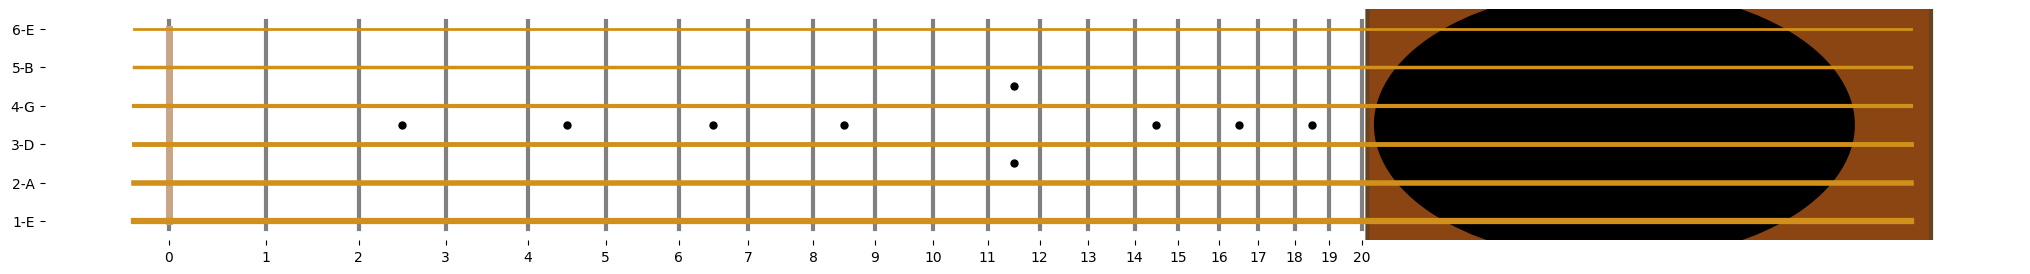

In [4]:
fig, ax = plt.subplots(figsize=(scale_length, 3))

ax = draw_fretboard(ax)


['C', 'D', 'E', 'F', 'G', 'A', 'B', 'C']


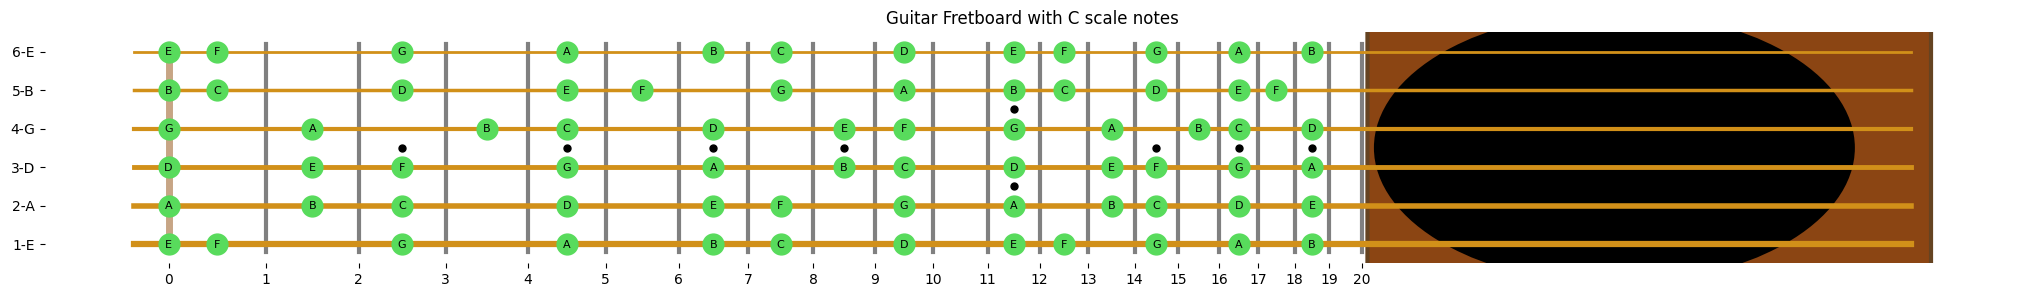

In [5]:
# Mark scale notes
scale_note = 'C'  # Example: C major scale
scale_notes = get_scale(scale_note, chromatic, maj_int)  # Example: C major scale
print(scale_notes)
fig, ax = plt.subplots(figsize=(scale_length, 3))
ax = draw_fretboard(ax)

ax = add_scale_to_fretboard(ax, scale_note, scale_notes)
ax.set_title(f'Guitar Fretboard with {scale_note} scale notes')

plt.show()


['C', 'E', 'G'] C Maj
['D', 'F', 'A'] D Min
['E', 'G', 'B'] E Min
['F', 'A', 'C'] F Maj
['G', 'B', 'C'] G Maj
['A', 'C', 'D'] A Min
['B', 'C', 'E'] B Dim


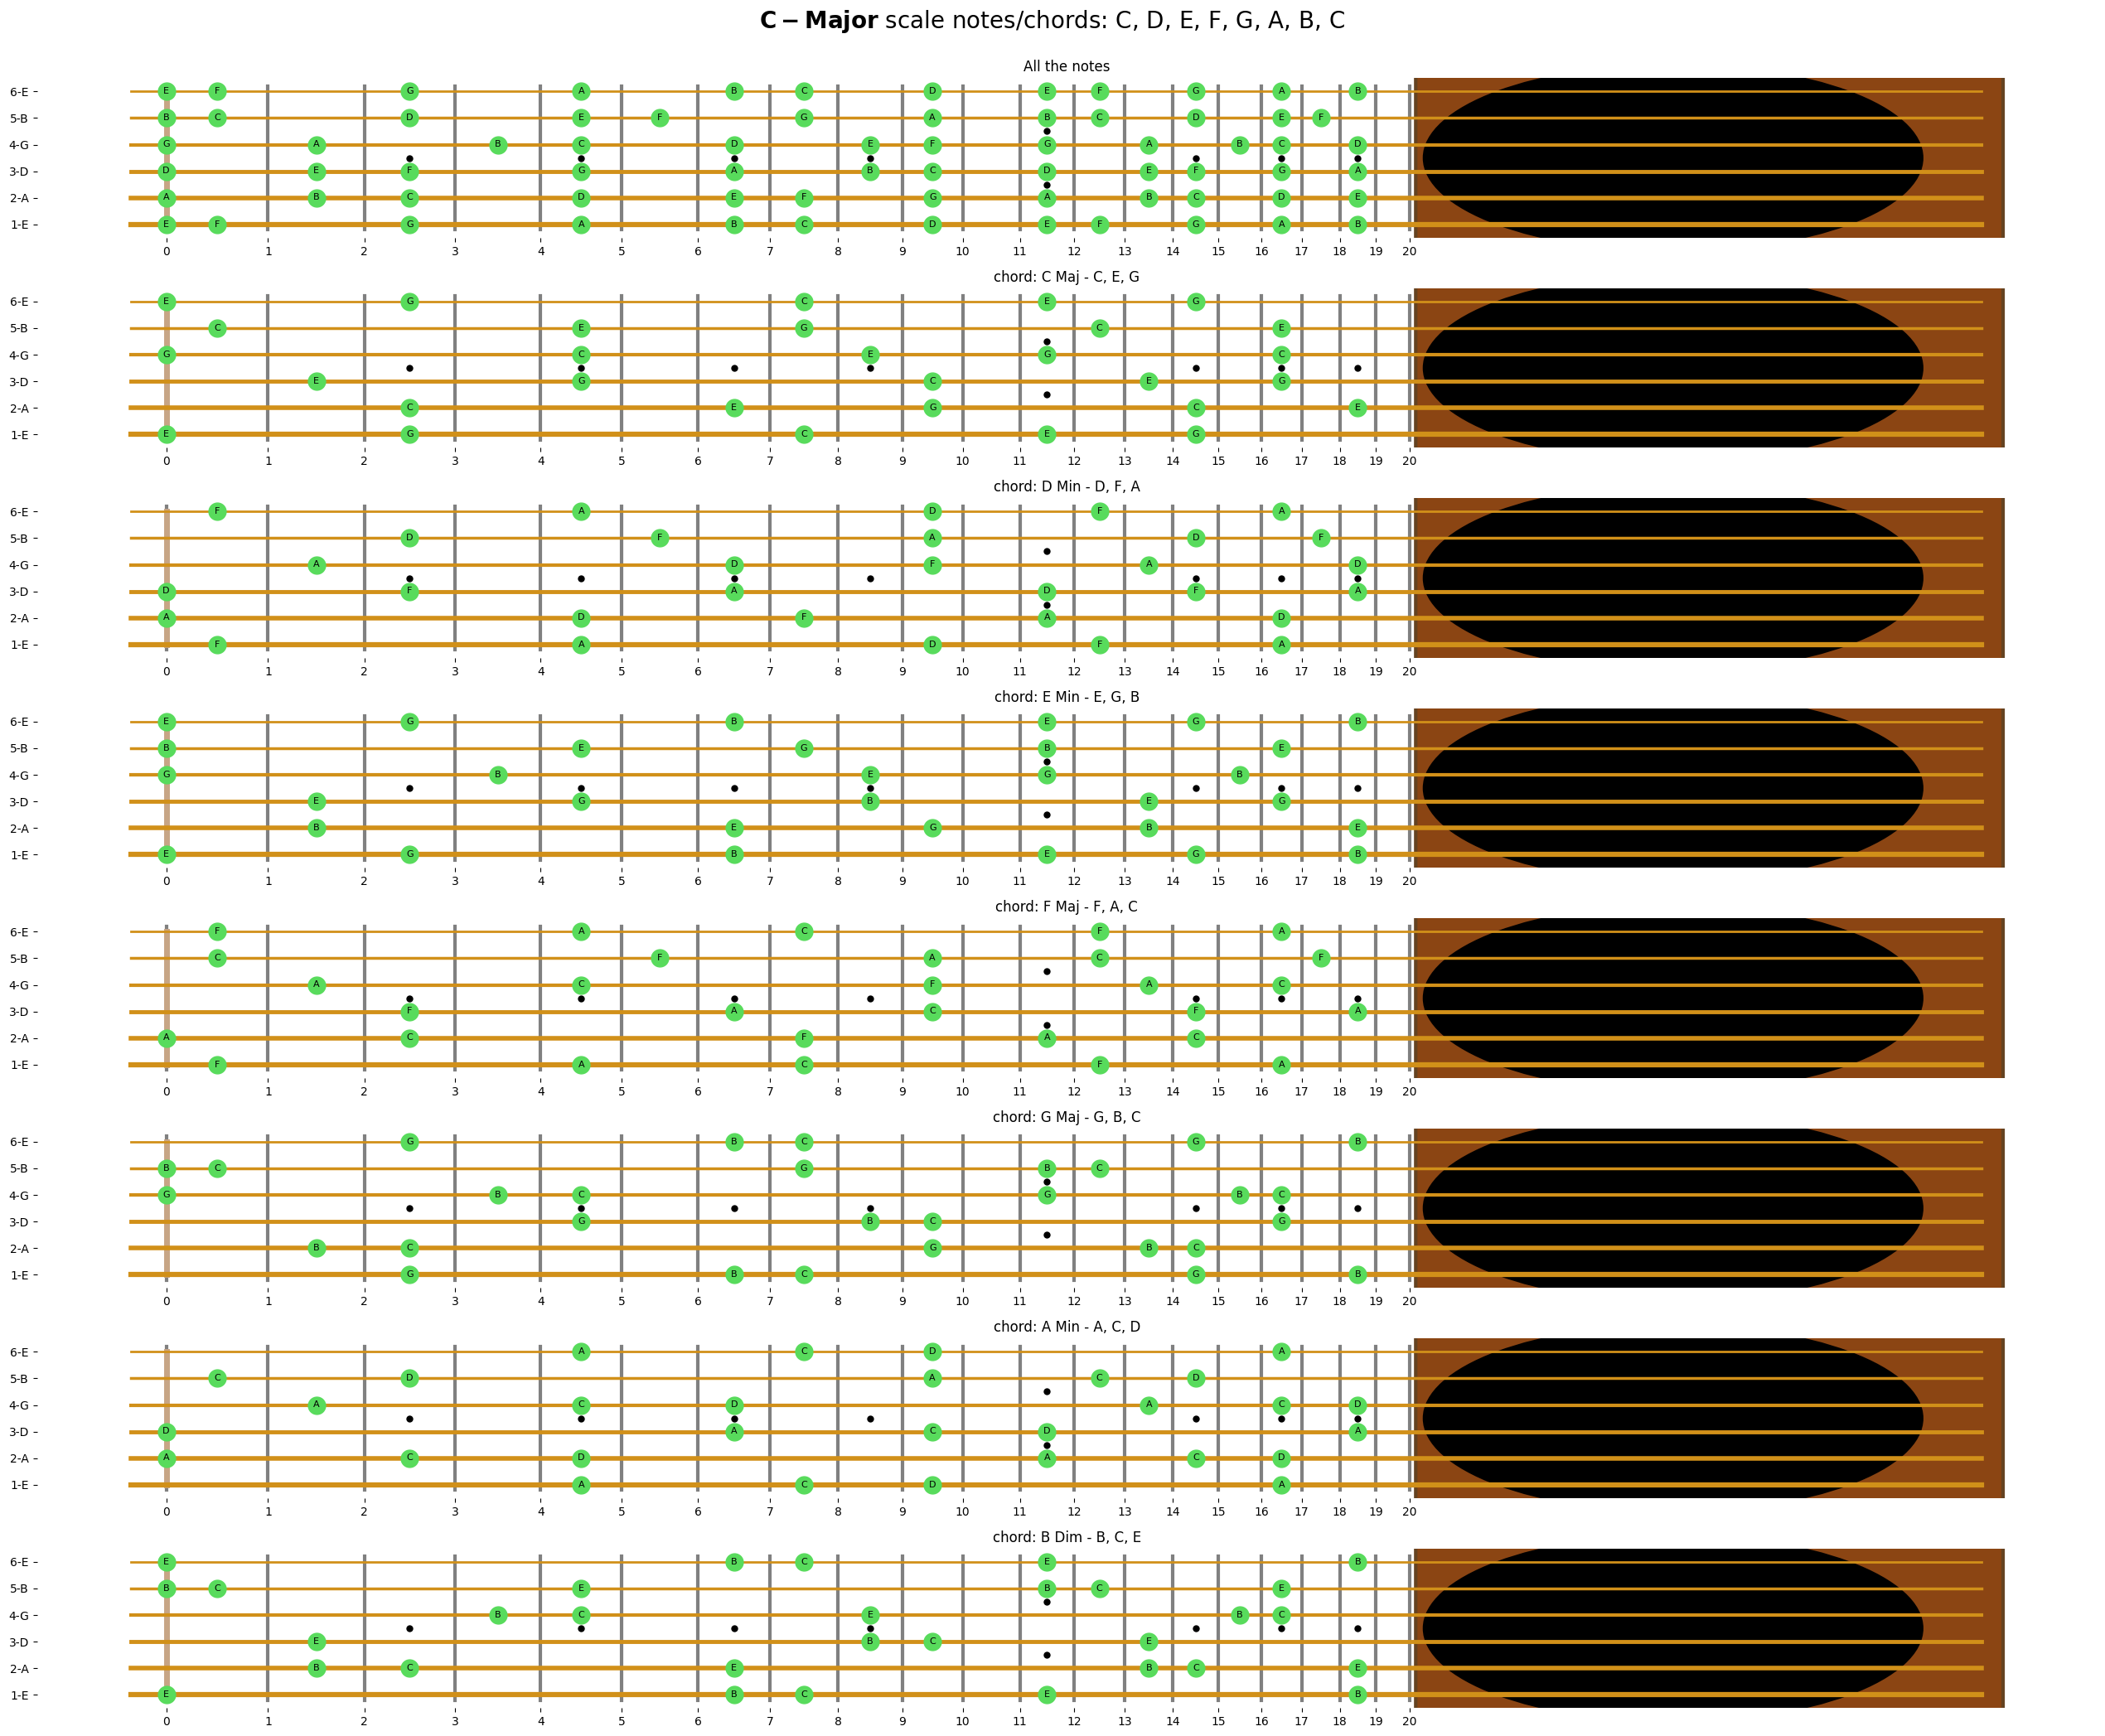

In [6]:
scale_note = 'C'  # Example: C major scale
scale_type = 'Major'  # Example: C major scale


scale_notes = get_scale(scale_note, chromatic, iterval_map[scale_type])  # Example: C major scale

# chords intervals using alternate triad notes from the scale
chord_intervals = [0, 2, 4]  # Root, third, fifth intervals for a triad chord
chord_types = ['Maj', 'Min', 'Min', 'Maj', 'Maj', 'Min', 'Dim']  # Example chord types for each root note in the scale
fig, axes = plt.subplots(8, 1, figsize=(scale_length, 22))  # 7 rows, 1 column

ax=axes[0]#.set_title(f'{scale_notes[j]} {chord_types[j]} chord: ' + ', '.join(chord_notes))
ax = draw_fretboard(ax)
ax = add_scale_to_fretboard(ax, scale_note, scale_notes)
ax.set_title(f'All the notes')


for j in range(7):  # Generate three chords by shifting the intervals
    chord_notes = [scale_notes[(i+j) % len(scale_notes)] for i in chord_intervals]
    print(chord_notes, scale_notes[j], chord_types[j])
    ax=axes[j+1]#.set_title(f'{scale_notes[j]} {chord_types[j]} chord: ' + ', '.join(chord_notes))
    ax = draw_fretboard(ax)
    ax = add_scale_to_fretboard(ax, scale_note, chord_notes)
    ax.set_title(f'chord: {scale_notes[j]} {chord_types[j]} - ' + ', '.join(chord_notes))
    #ax.set_aspect('equal')  # Keep the aspect ratio of the fretboard consistent

#ax.set_aspect('equal')  # Keep the aspect ratio of the fretboard consistent


fig.suptitle(f'$\\bf{{{scale_note}-{scale_type}}}$ scale notes/chords: {", ".join(scale_notes)}', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust layout to make room for the suptitle
fig.savefig(f'{scale_note}_{scale_type}_fretboard.pdf', dpi=300)  # Save the figure as a PNG file with high resolution
plt.show()

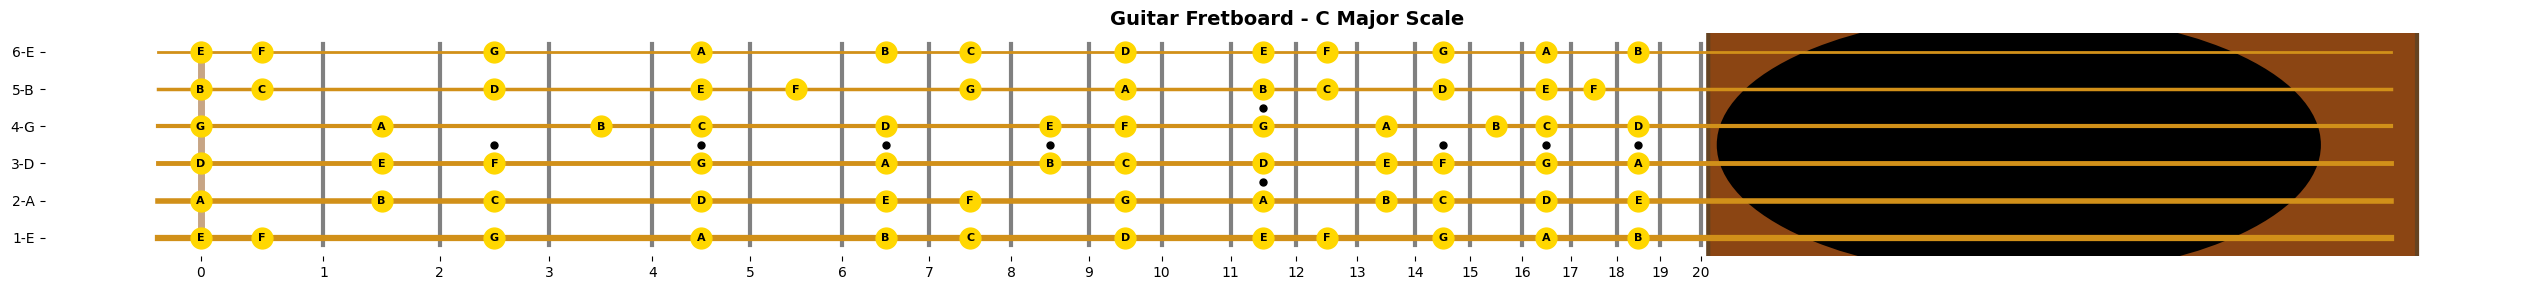

C Major scale notes: ['C', 'D', 'E', 'F', 'G', 'A', 'B', 'C']
Chord 1: G Maj - ['G', 'A#', 'D']
Chord 2: A Min - ['A', 'C', 'D#']
Chord 3: A# Min - ['A#', 'D', 'F']
Chord 4: C Maj - ['C', 'D#', 'G']
Chord 5: D Maj - ['D', 'F', 'G']
Chord 6: D# Min - ['D#', 'G', 'A']
Chord 7: F Dim - ['F', 'G', 'A#']


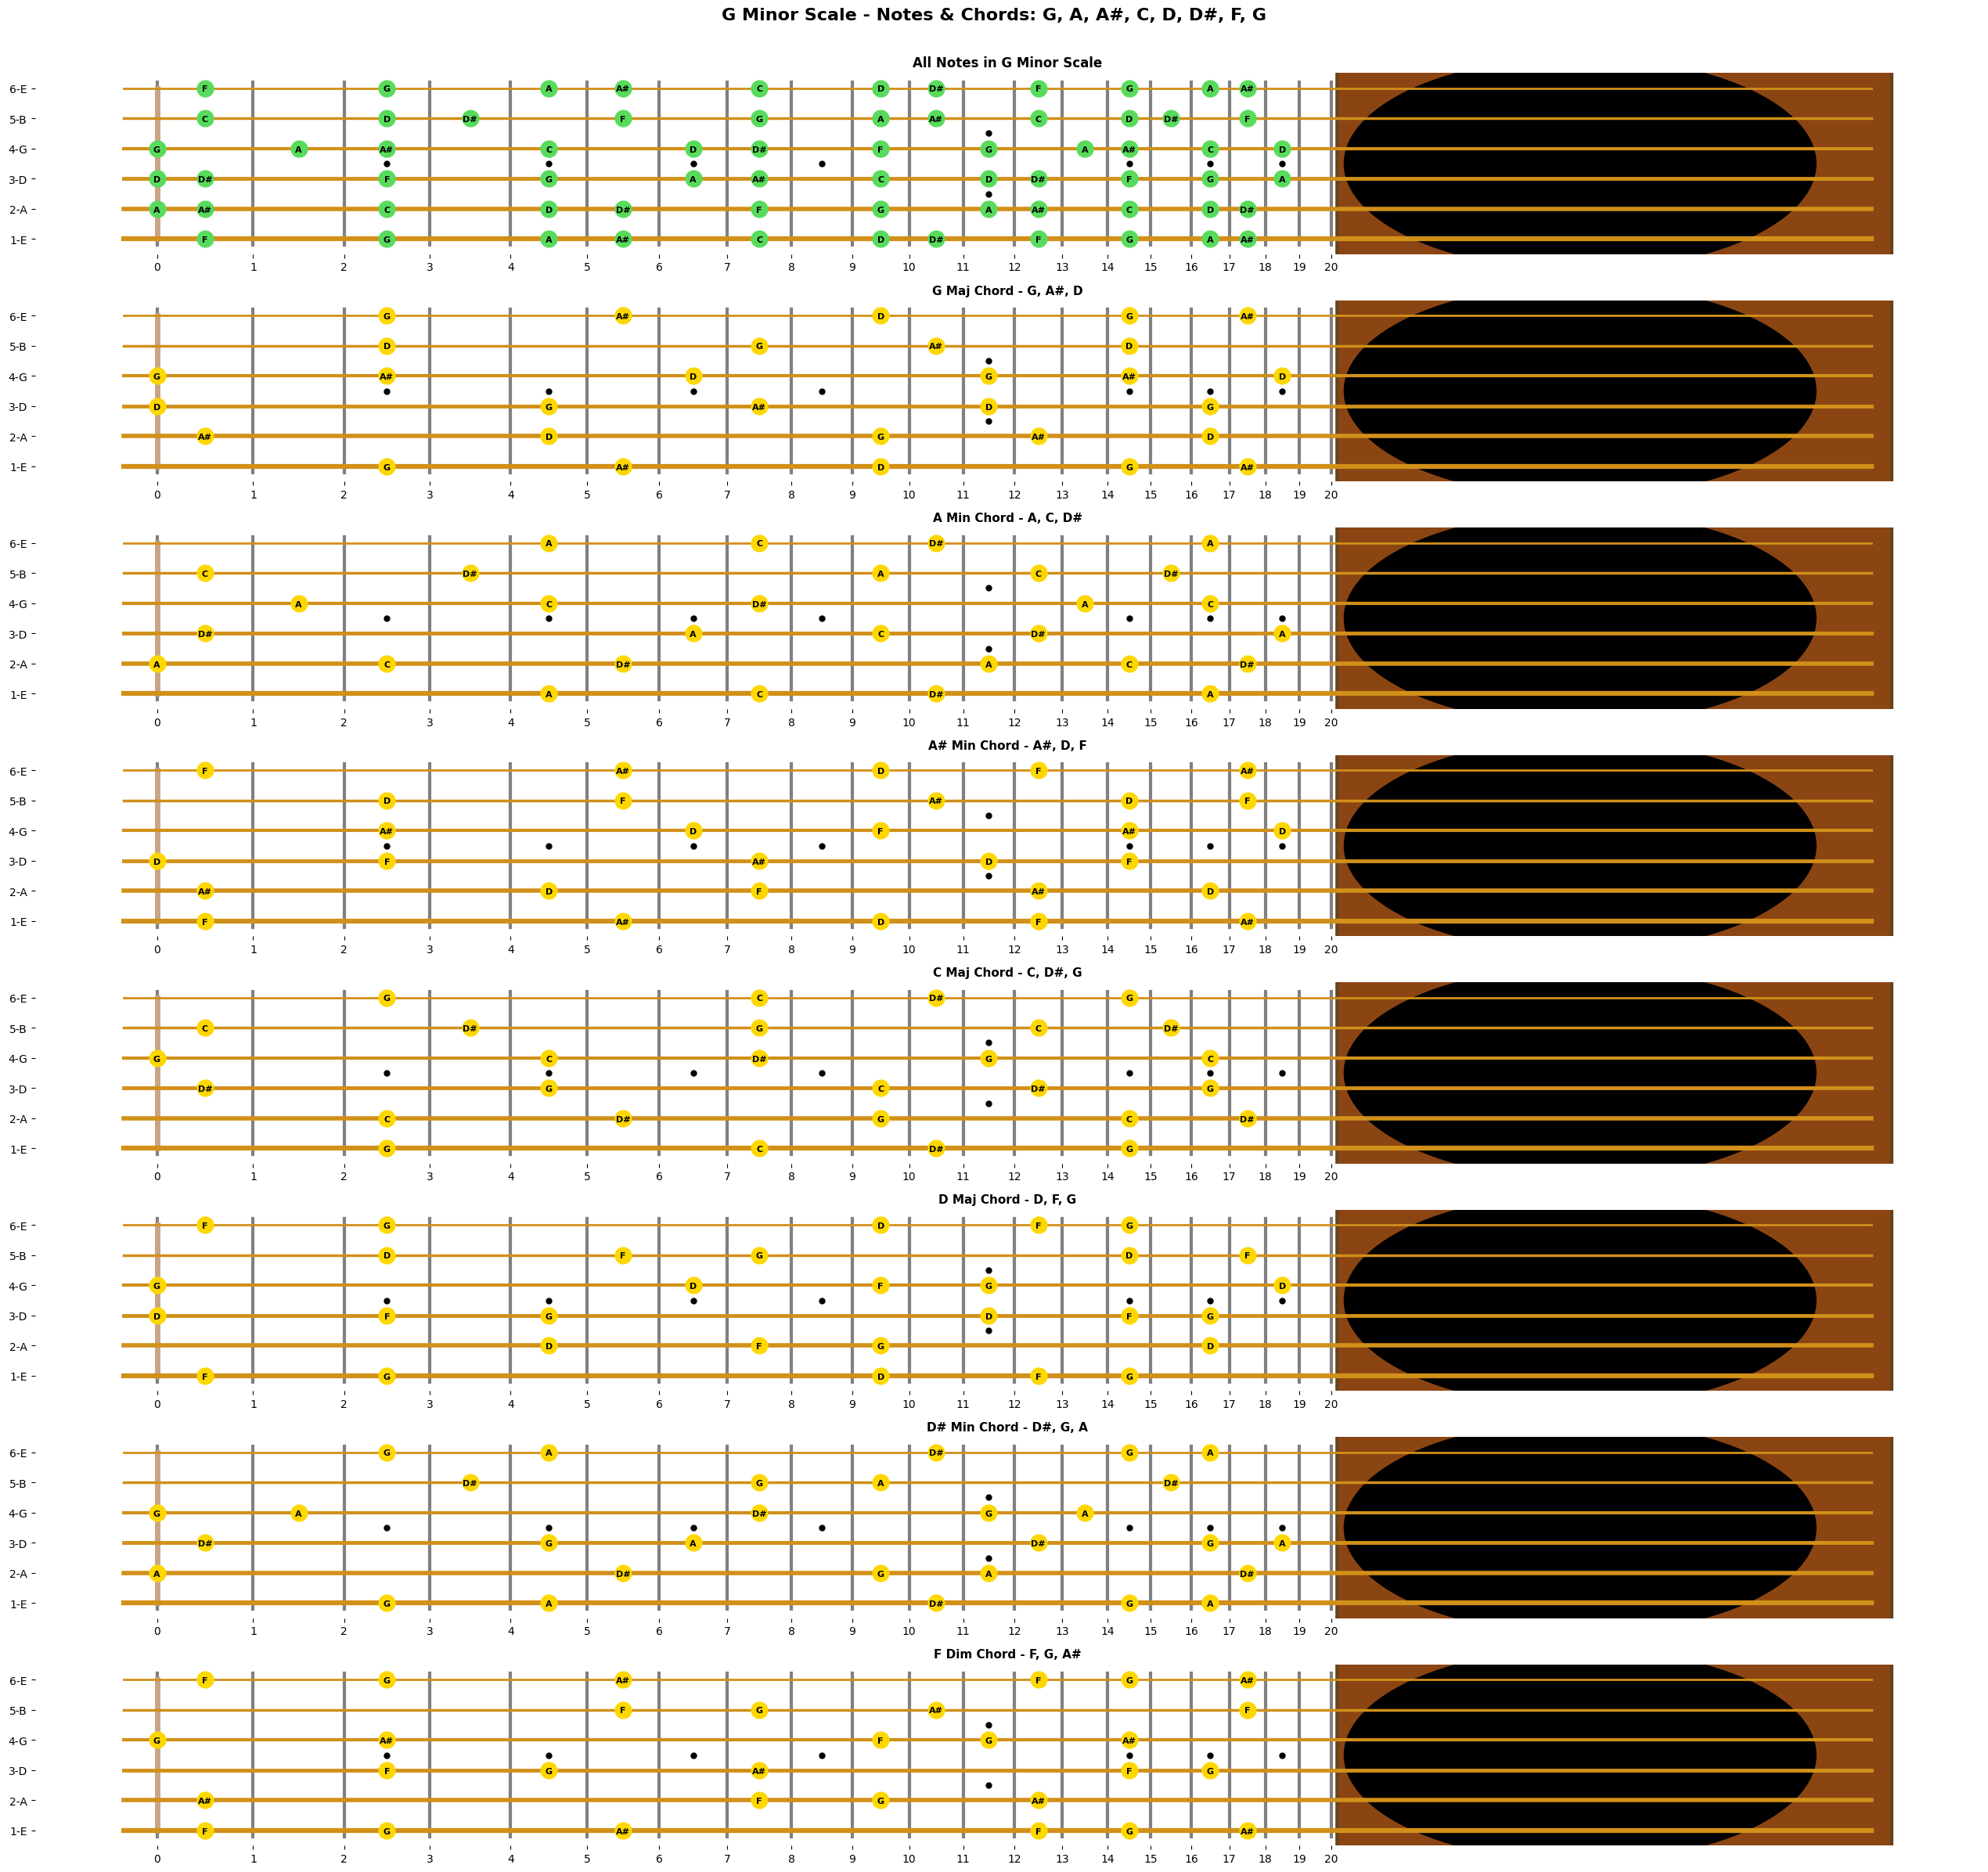

A Major: ['A', 'B', 'C#', 'D', 'E', 'F#', 'G#', 'A']
A Minor: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'A']
A Pentatonic: ['A', 'B', 'C#', 'E', 'F#', 'A']
A Blues: ['A', 'C', 'D', 'D#', 'E', 'G', 'A']


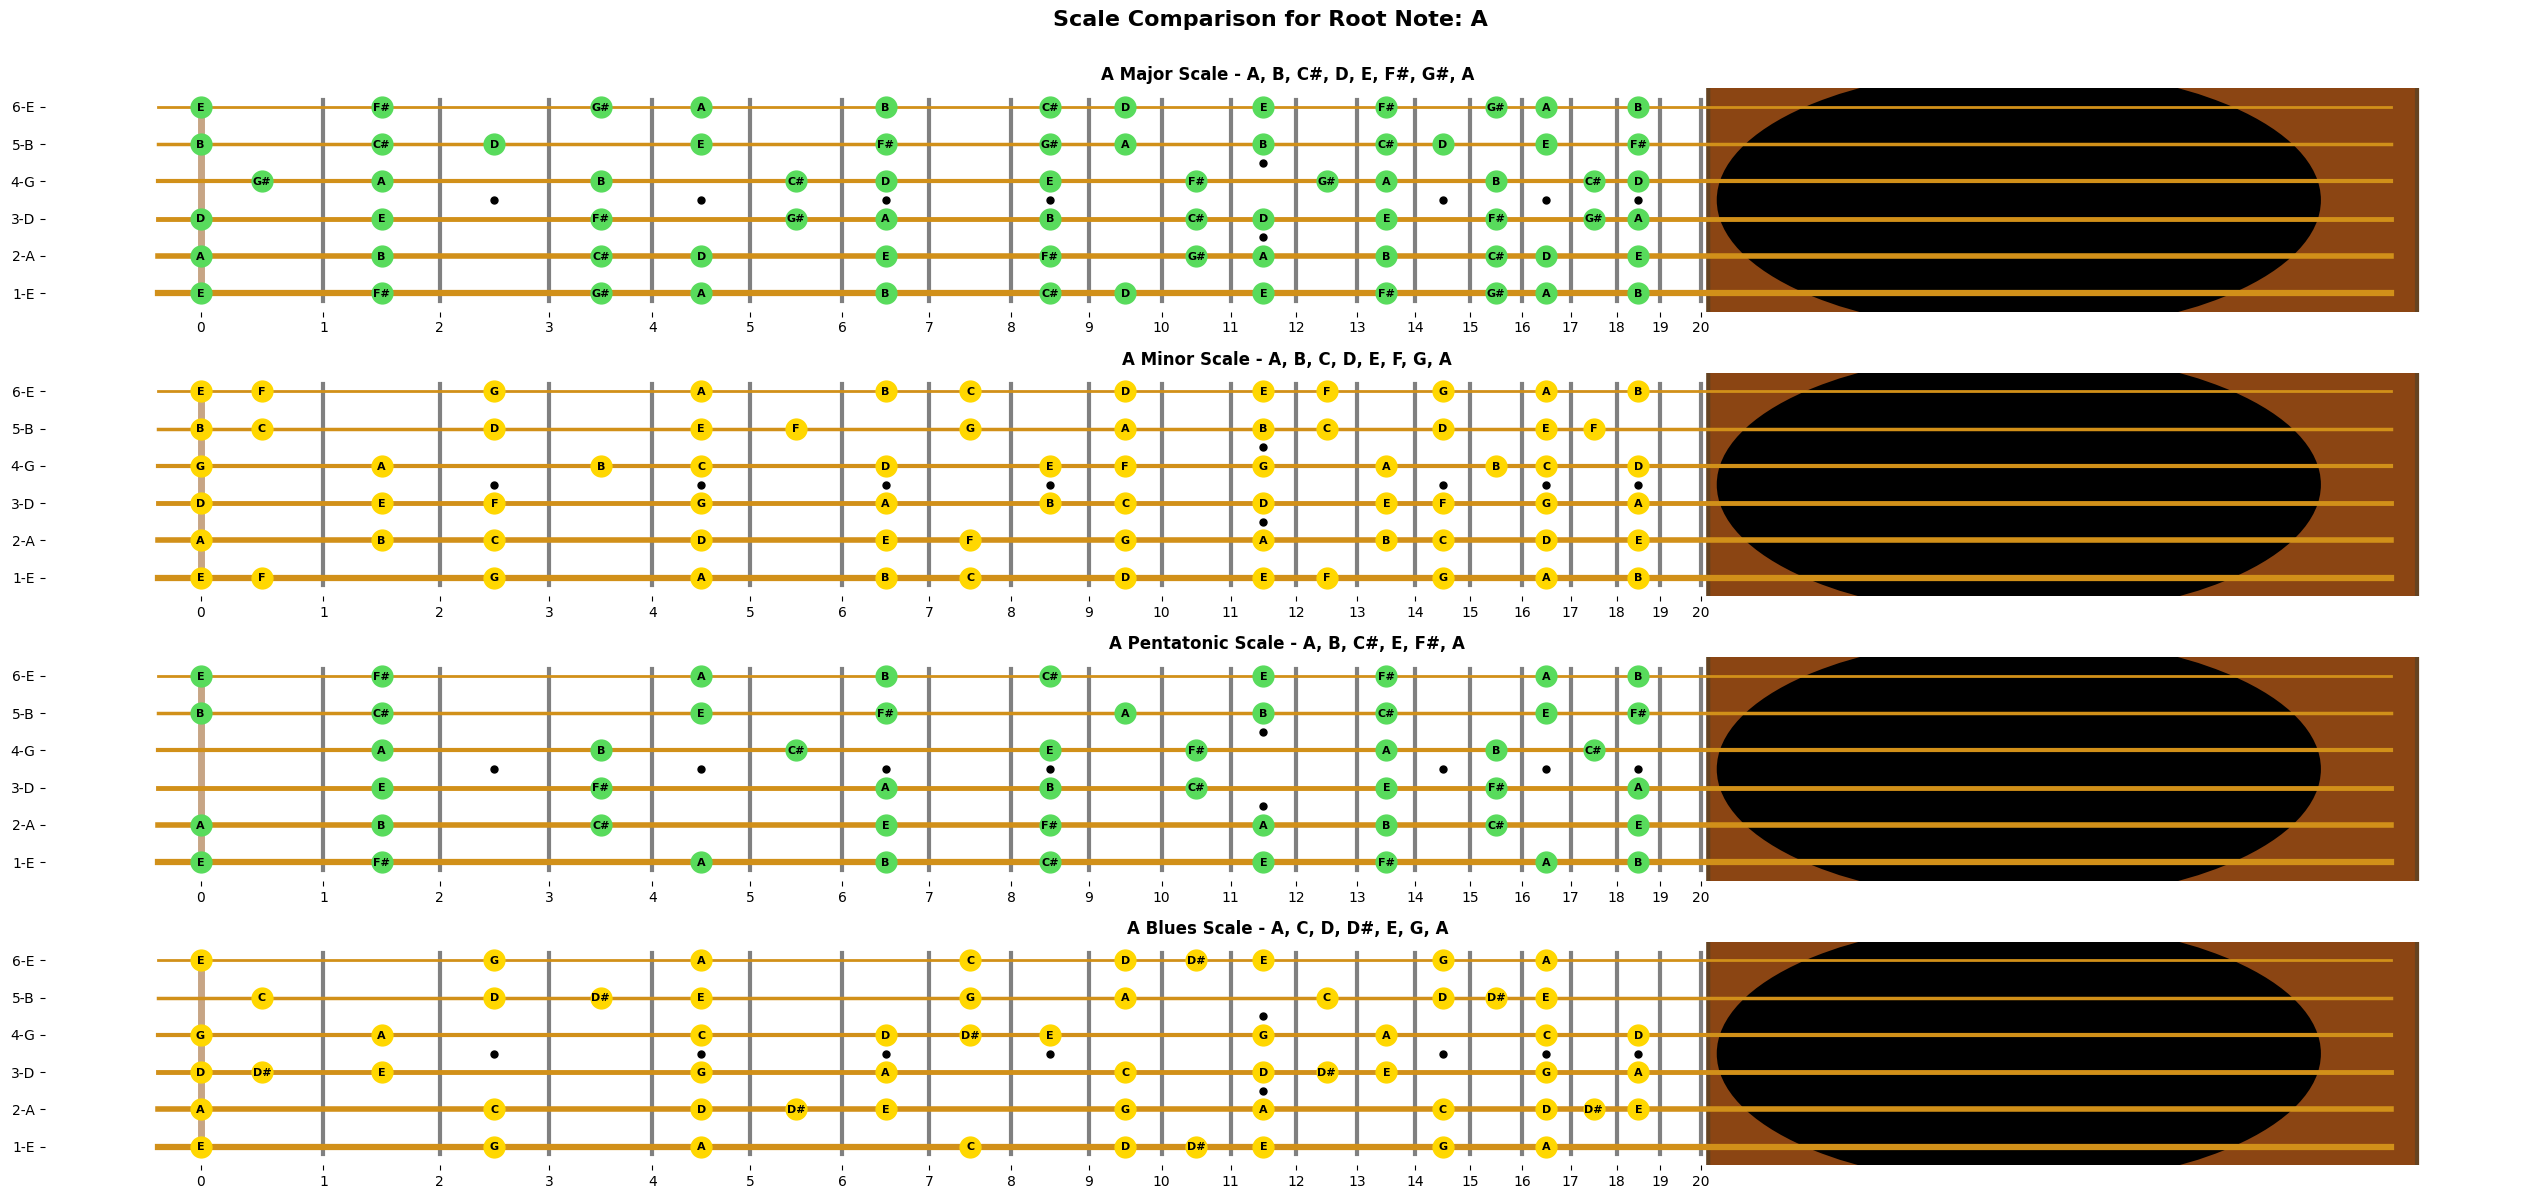

D Ionian (Major): ['D', 'E', 'F#', 'G', 'A', 'B', 'C#', 'D']
D Dorian: ['D', 'E', 'F', 'G', 'A', 'B', 'C', 'D']
D Phrygian: ['D', 'D#', 'F', 'G', 'A', 'A#', 'C', 'D']
D Lydian: ['D', 'E', 'F#', 'G#', 'A', 'B', 'C#', 'D']
D Mixolydian: ['D', 'E', 'F#', 'G', 'A', 'B', 'C', 'D']
D Aeolian (Minor): ['D', 'E', 'F', 'G', 'A', 'A#', 'C', 'D']
D Locrian: ['D', 'D#', 'F', 'G', 'G#', 'A#', 'C', 'D']


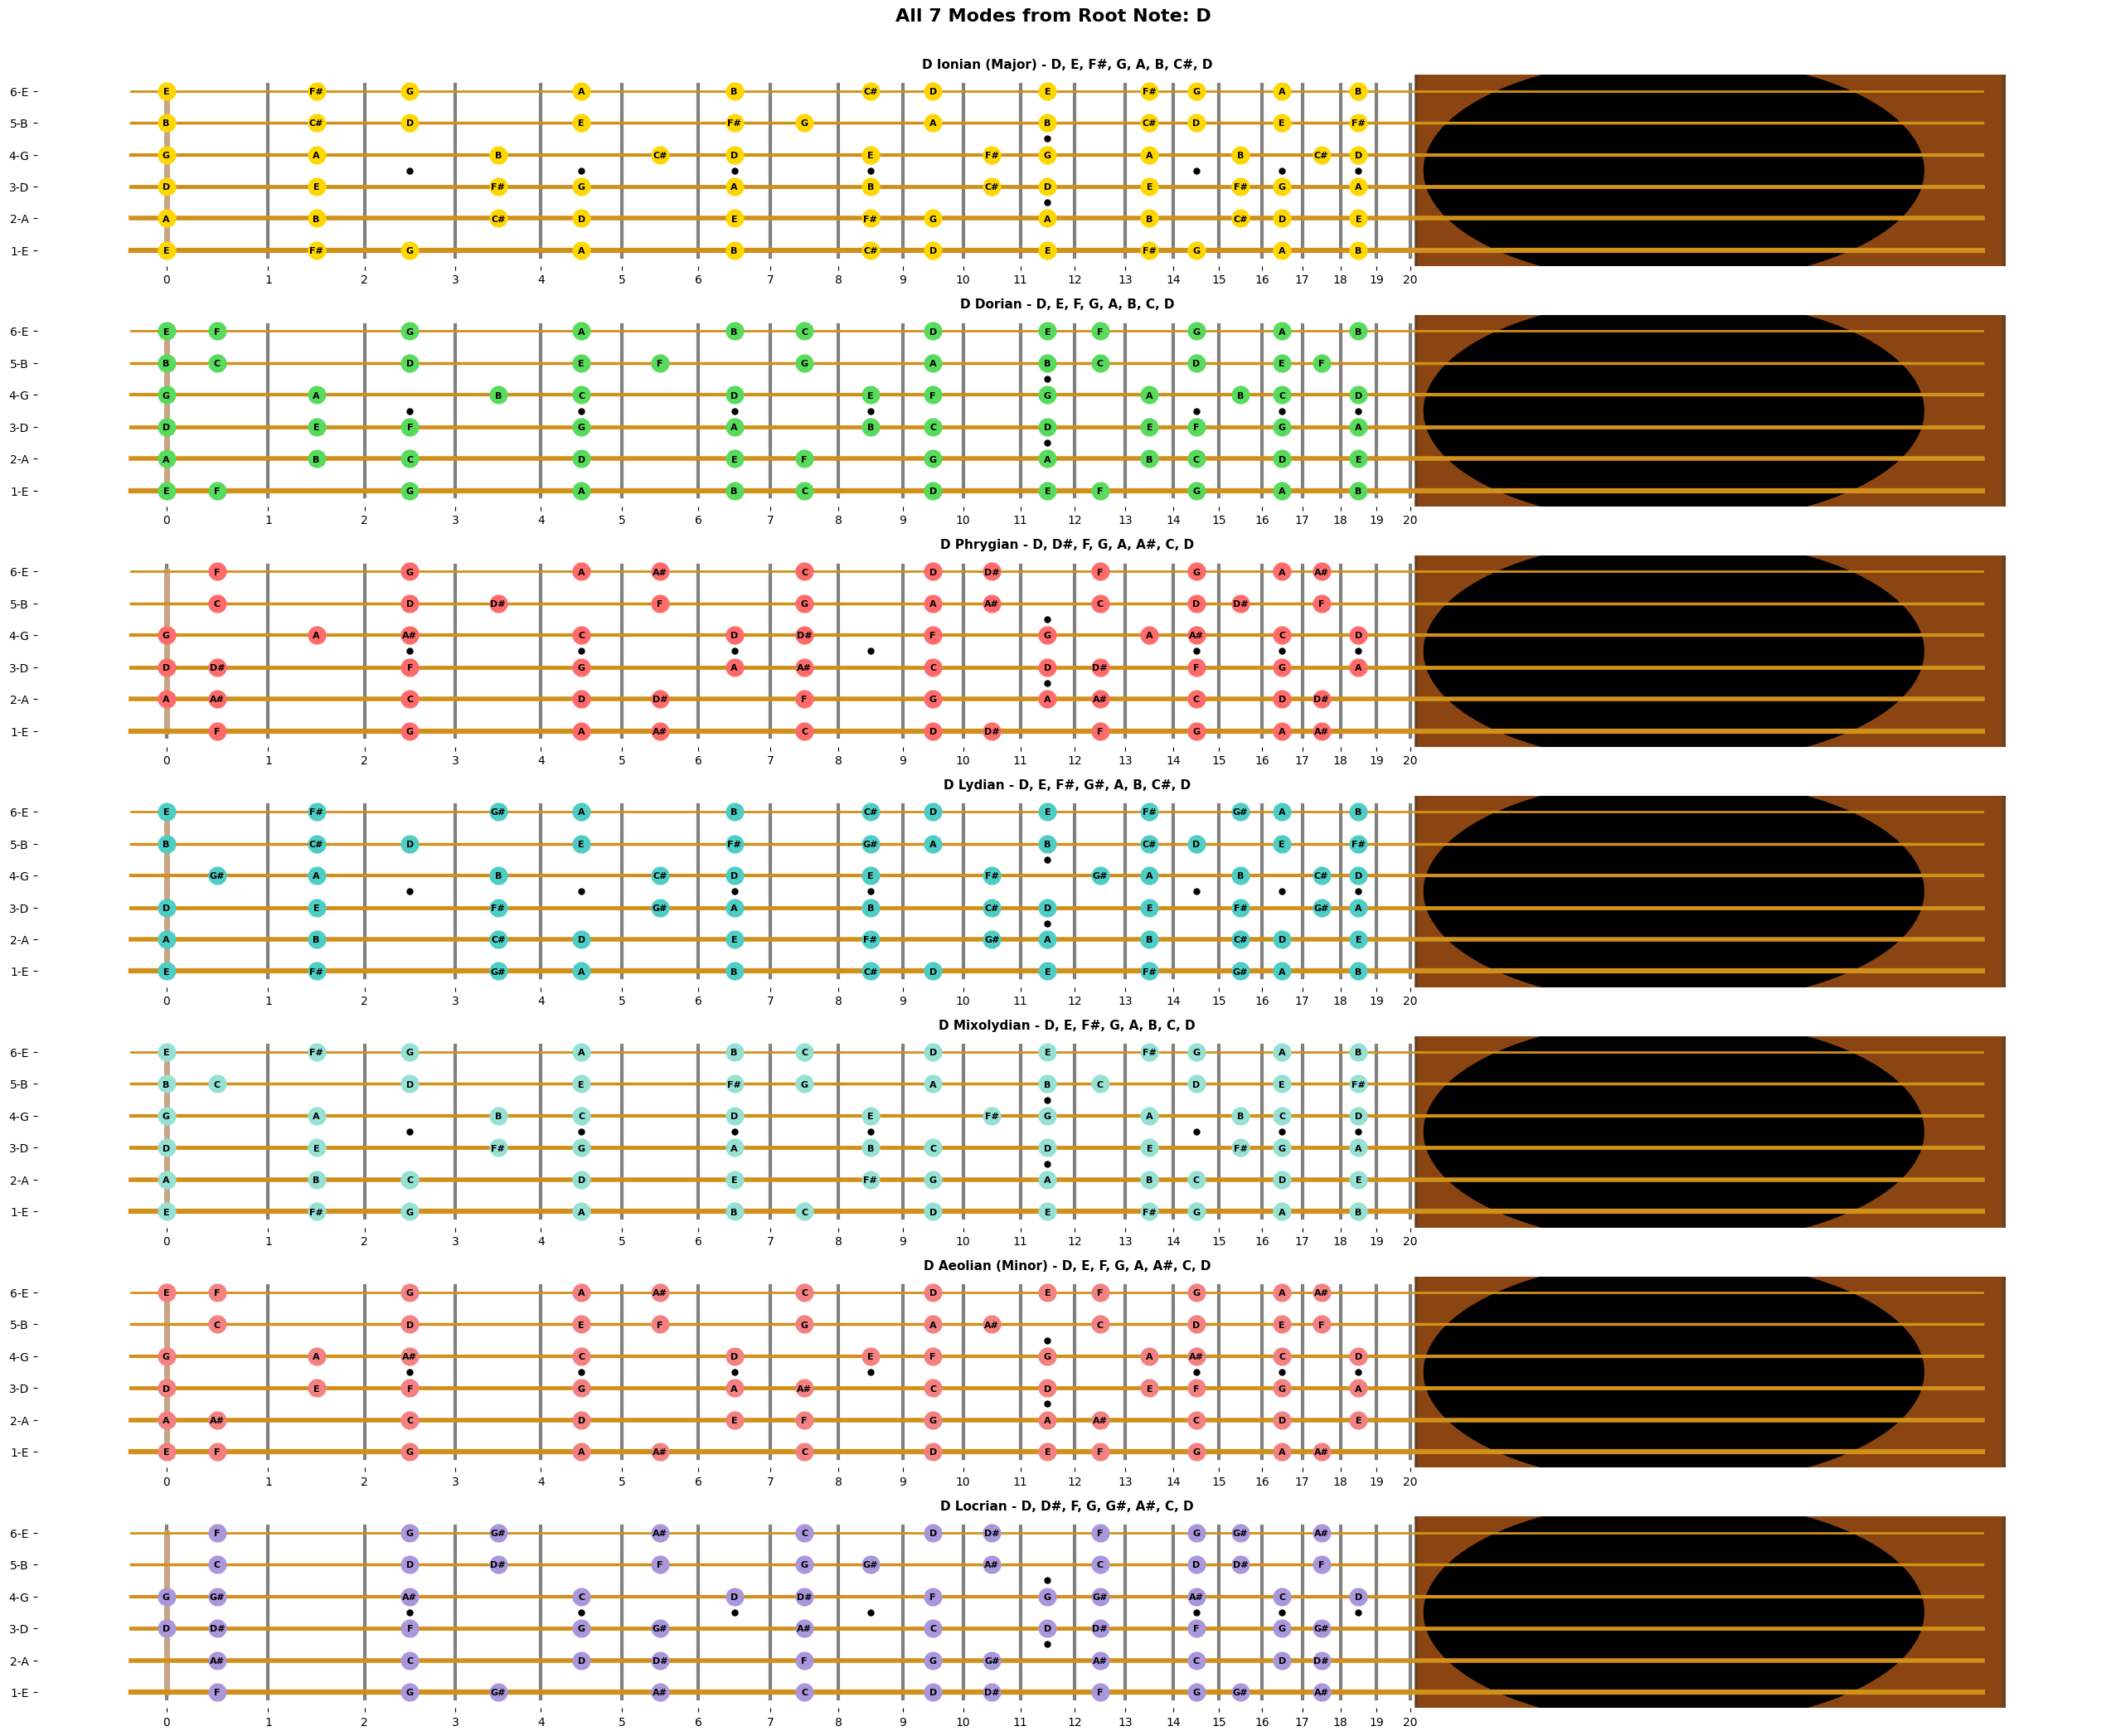

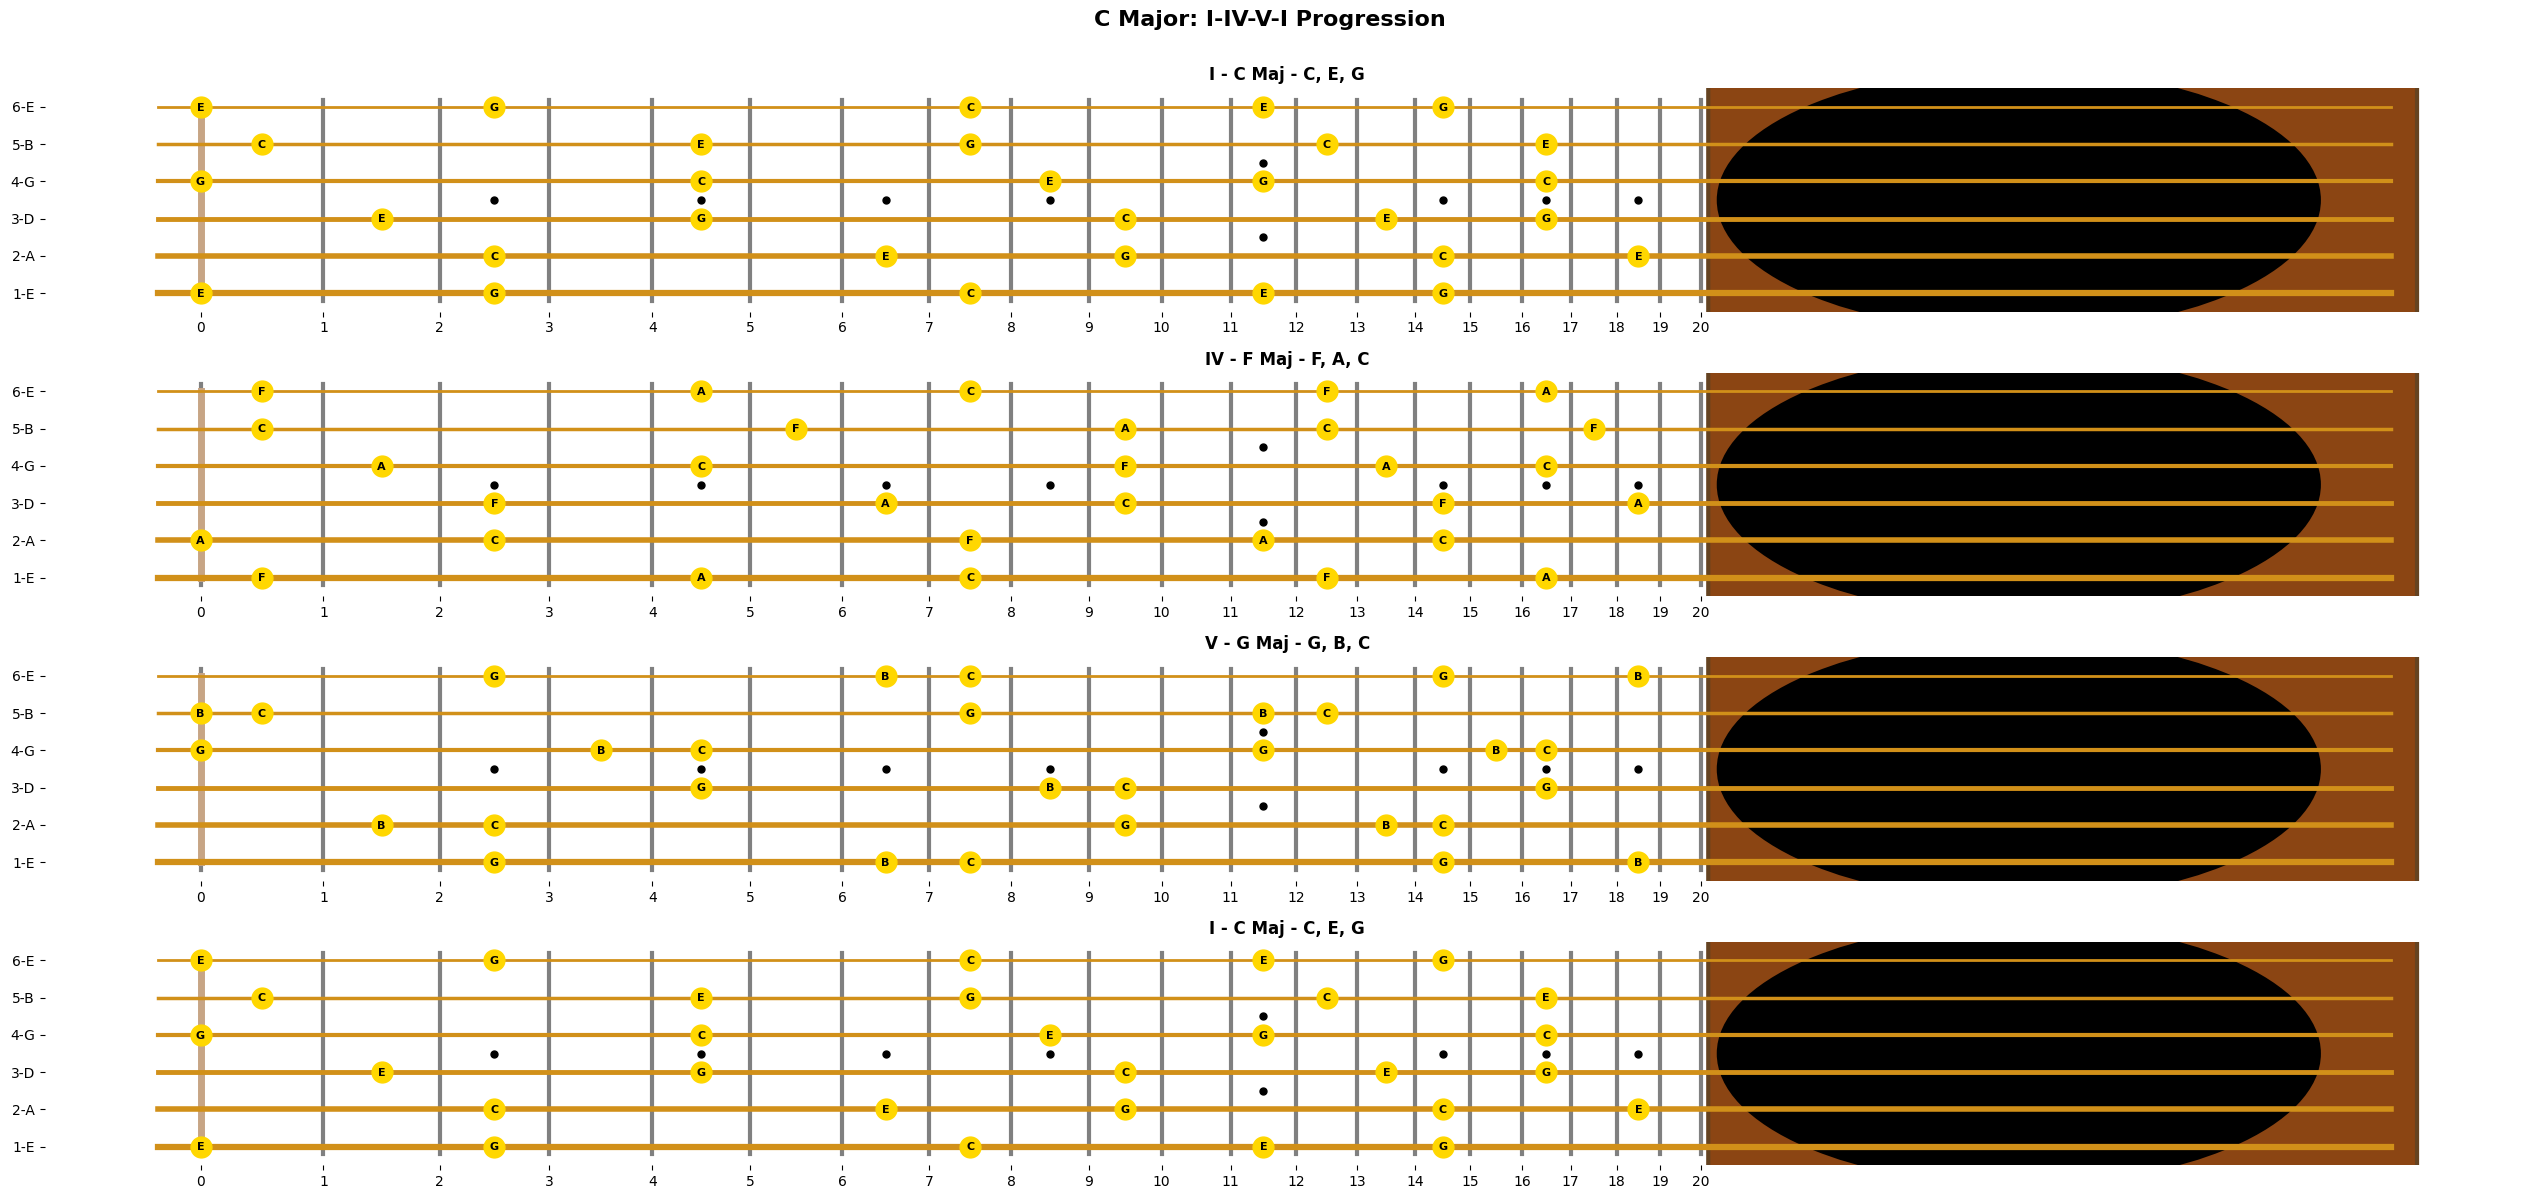

In [7]:
# Import the script
from guitar import *

# Now use the functions directly

# USE CASE 1: Single scale
visualize_single_scale('C', 'Major')

# USE CASE 2: Scale with chords
visualize_scale_with_chords('G', 'Minor')

# USE CASE 3: Compare scales
compare_scales('A', ['Major', 'Minor', 'Pentatonic', 'Blues'])

# USE CASE 4: All modes
visualize_all_modes('D')

# USE CASE 5: Chord progression
visualize_chord_progression('C', 'Major', [0, 3, 4, 0])  # I-IV-V-I

In [10]:
%matplotlib inline
from IPython.display import clear_output

from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
from guitar import *


# Modified function without plt.show() for widgets
def visualize_single_scale_interactive(scale_note='C', scale_type='Major'):
    plt.close('all')  # Close previous plots
    clear_output(wait=True)  # Clear output

    """Visualize a single scale on the fretboard (for interactive use)"""
    scale_notes = get_scale(scale_note, chromatic, interval_map[scale_type])
    
    fig, ax = plt.subplots(figsize=(scale_length, 3), facecolor='white')
    ax = draw_fretboard(ax)
    ax = add_scale_to_fretboard(ax, scale_note, scale_notes)
    ax.set_title(f'Guitar Fretboard - {scale_note} {scale_type} Scale', 
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    #plt.show()  # This is OK in notebook with %matplotlib widget
    
    #print(f"{scale_note} {scale_type} scale notes: {scale_notes}")

# Create interactive dropdowns
@interact(
    scale_note=Dropdown(options=chromatic, value='C', description='Root Note:'),
    scale_type=Dropdown(options=list(interval_map.keys()), value='Major', description='Scale Type:')
)
def interactive_scale(scale_note, scale_type):
    visualize_single_scale_interactive(scale_note, scale_type)

interactive(children=(Dropdown(description='Root Note:', index=3, options=('A', 'A#', 'B', 'C', 'C#', 'D', 'D#…

In [11]:
%matplotlib inline
from IPython.display import clear_output
from guitar import *
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
def visualize_single_scale_widget(scale_note='C', scale_type='Major'):
    """Widget-friendly version"""
    #from IPython.display import clear_output
    plt.close('all')  # Close all previous figures

    clear_output(wait=True)
    
    scale_notes = get_scale(scale_note, chromatic, interval_map[scale_type])
    
    fig, ax = plt.subplots(figsize=(scale_length, 3), facecolor='white')
    ax = draw_fretboard(ax)
    ax = add_scale_to_fretboard(ax, scale_note, scale_notes)
    ax.set_title(f'{scale_note} {scale_type} Scale', fontsize=14, fontweight='bold')

    #plt.tight_layout()
    #display(fig)  # Use display instead of show
    #plt.close(fig)  # Close to avoid duplicate display    
    plt.show()# or plt.savefig()

interact(
    visualize_single_scale_widget,
    scale_note=Dropdown(options=chromatic, value='C'),
    scale_type=Dropdown(options=list(interval_map.keys()), value='Major')
);

interactive(children=(Dropdown(description='scale_note', index=3, options=('A', 'A#', 'B', 'C', 'C#', 'D', 'D#…

2026-03-01 01:25:21.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 01:25:21.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

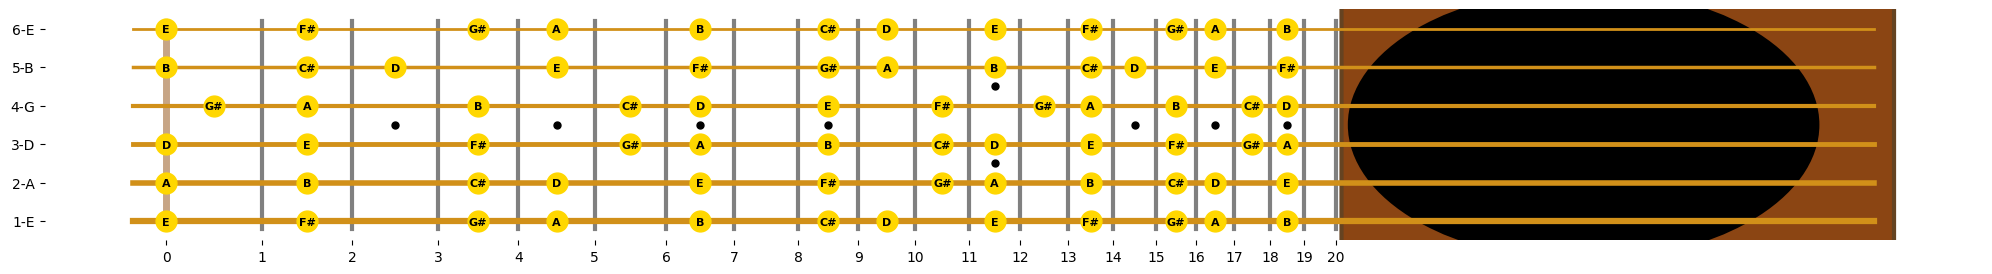

In [14]:
# 1. Create streamlit_app.py
import streamlit as st
from guitar import *

st.title("🎸 Guitar Fretboard Visualizer")
note = st.selectbox("Root Note", chromatic)
scale = st.selectbox("Scale", list(interval_map.keys()))

scale_notes = get_scale(note, chromatic, interval_map[scale])
fig, ax = plt.subplots(figsize=(25, 3))
ax = draw_fretboard(ax)
ax = add_scale_to_fretboard(ax, note, scale_notes)
st.pyplot(fig)